In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import xesmf as xe                     #package for regridding 

#import gravity toolkit 
import gravity_toolkit as gravtk

#from scipy import signal              #not sure if I need those
#import importlib
import sys
sys.path.append('../code')

xESMF is installed! Version: 0.8.7


In [2]:
data_path = '../data/GravIs/'


In [34]:
#Open the COST-G and GFZ dataset to compare 
ant = xr.open_dataset(data_path + "GRAVIS-3_COSTG_0100_AIS_GRID_TUD_0003.nc")
ant2 = xr.open_dataset(data_path + "GRAVIS-3_GFZOP_0600_AIS_GRID_TUD_0004.nc")

#print(ant)
ant

<xarray.Dataset> Size: 22MB
Dimensions:   (time: 240, y: 97, x: 117)
Coordinates:
  * x         (x) float64 936B -2.9e+06 -2.85e+06 -2.8e+06 ... 2.85e+06 2.9e+06
  * y         (y) float64 776B -2.4e+06 -2.35e+06 -2.3e+06 ... 2.35e+06 2.4e+06
  * time      (time) datetime64[ns] 2kB 2002-04-18 ... 2024-12-16T12:00:00
Data variables:
    time_dec  (time) float64 2kB ...
    lon       (y, x) float64 91kB ...
    lat       (y, x) float64 91kB ...
    dm        (time, y, x) float64 22MB ...
    area      (y, x) float64 91kB ...
    crs       |S1 1B ...
Attributes: (12/16)
    title:                Gridded AIS Mass Changes
    institution:          TU Dresden, Chair of Geodetic Earth System Research
    authors:              Andreas Groh, Martin Horwath, Thorben Döhne
    project:              GravIS GRACE/GRACE-FO Level-3 Products
    source:               Monthly COST-G RL01 GRACE/GRACE-FO Level-2B product...
    summary:              GRACE/GRACE-FO derived time series of gridded Antar...
    ...                   ...
    product_version:      0003
    doi:                  10.5880/COST-G.GRAVIS_01_L3_ICE
    netCDF_version:       netCDF-4_classic
    conventions:          CF-1.6
    date_created:         2025-04-07
    contact:              thorben.doehne@tu-dresden.de

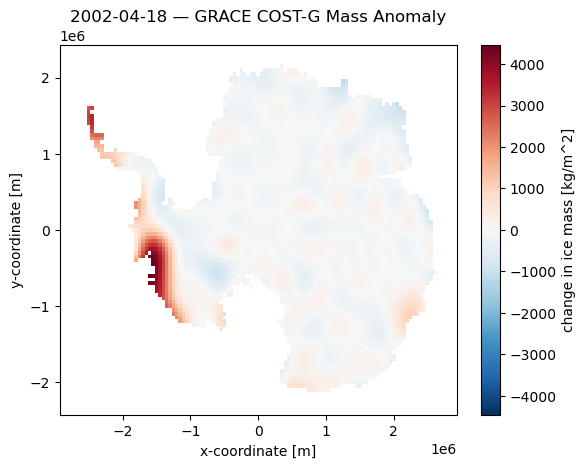

In [27]:
# Plot first time step
ant["dm"].isel(time=0).plot()
#    cmap="RdBu_r",  # red-blue colormap (blue = mass gain, red = loss)
#    robust=True
#)
plt.title(str(ant["time"].values[0])[:10] + " — GRACE COST-G Mass Anomaly")
plt.show()


In [28]:
#ant0 = ant.isel(x=44, y=55)
#ant0

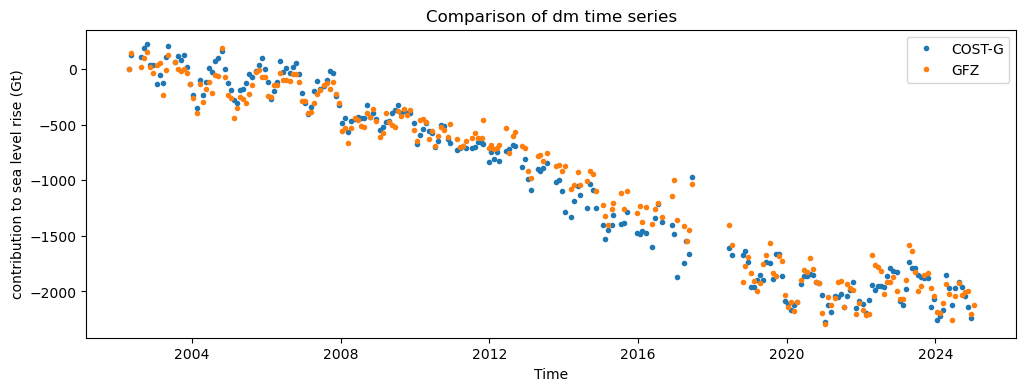

Average mass loss rate (COST-G): -112.83 Gt/yr
Average mass loss rate (GFZ):    -107.43 Gt/yr


In [127]:
# Create dataset with total mass loss over Antarctica

antsum = (ant['dm']*ant['area']).sum(dim=['x', 'y'], skipna=True)*10**(-12)  # Multiply the dm (kg per square meter ice loss) with the area to ge total ice loss, then sum over all cells to get total mass loss and translate to Gt
antsum2 = (ant2['dm']*ant2['area']).sum(dim=['x', 'y'], skipna=True)*10**(-12)

# Relative to t=0 
antsum_rel = antsum - antsum.isel(time=0)
antsum2_rel = antsum2 - antsum2.isel(time=0)
test_rel = test - test.isel(time=0)

#Make a figure 
plt.figure(figsize=(12,4)) 

antsum_rel.plot(marker='.', linestyle='', label='COST-G')
antsum2_rel.plot(marker='.', linestyle='', label='GFZ')

plt.xlabel("Time")
plt.ylabel("contribution to sea level rise (Gt)")
plt.title("Comparison of dm time series")
plt.legend()
plt.show()


#ff iets testen
# Convert time to numeric years (decimal)
time_years = antsum['time'].dt.year + antsum['time'].dt.dayofyear / 365.25
time_years2 = antsum2['time'].dt.year + antsum2['time'].dt.dayofyear / 365.25
# Linear trend (slope = Gt/yr)
slope1, intercept1 = np.polyfit(time_years, antsum_rel, 1)
slope2, intercept2 = np.polyfit(time_years2, antsum2_rel, 1)
print(f"Average mass loss rate (COST-G): {slope1:.2f} Gt/yr")
print(f"Average mass loss rate (GFZ):    {slope2:.2f} Gt/yr")




In [124]:
#check times
#time_list = antsum["time"].dt.strftime("%Y-%m-%d").values
#print(time_list)
#print(antsum['dm'].values)
# antsum is your 1D DataArray: sum over all coordinates per timestep
#antsum_interp = antsum.interpolate_na(dim="time", method="linear")
#antsum_interp.plot(marker='.', linestyle='', figsize=(12,4))




#Regridding to use in GRD 

<xarray.DataArray (lat: 180, lon: 360)> Size: 518kB
array([[220.3       , 220.3       , 220.3       , ..., 220.3       ,
        220.3       , 220.3       ],
       [152.41078446, 152.01490079, 151.63413041, ..., 156.63960609,
        155.21340259, 153.8039105 ],
       [127.98022276, 129.1757845 , 130.35712211, ..., 130.87758888,
        129.91875331, 128.95384904],
       ...,
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ]], shape=(180, 360))
Coordinates:
    lat      (lat, lon) int64 518kB -90 -90 -90 -90 -90 -90 ... 89 89 89 89 89
    lon      (lat, lon) int64 518kB 0 1 2 3 4 5 6 ... 354 355 356 357 358 359

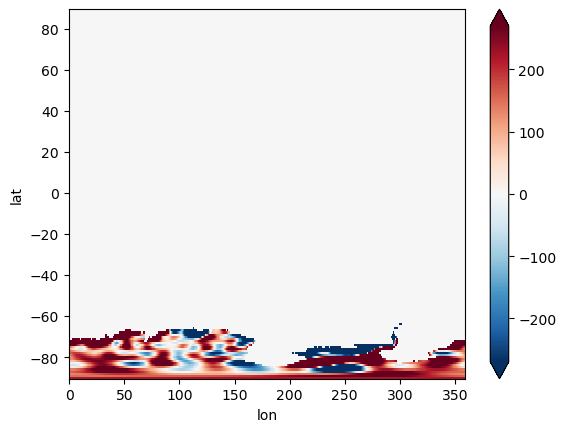

In [125]:
# Regridding 

#define resolution reference grid:
lon_res = 1
lat_res = 1

lon_target = np.arange(0, 360 , lon_res)
lat_target = np.arange(-90, 90 , lat_res)  

lon2d, lat2d = np.meshgrid(lon_target, lat_target)   #creats lon lat pairs

ds_out = xr.Dataset(
    {
        "lat": (["lat", "lon"], lat2d),
        "lon": (["lat", "lon"], lon2d)
    }
)

# --- Step 2: Create regridder ---
regridder = xe.Regridder(ant, ds_out, "bilinear", periodic=False, reuse_weights=False, unmapped_to_nan=True)


# --- Step 3: Regrid dm to lon-lat grid ---
dm_lonlat = regridder(ant["dm"])
# Optional: Regrid area too if you need to recompute total mass
area_lonlat = regridder(ant["area"])


# Optional: replace NaNs with 0
dm_lonlat_zero = dm_lonlat.fillna(0)
area_lonlat_zero = area_lonlat.fillna(0)



# --- Step 4: Compute total mass per time step in Gt ---
# 1 Gt = 1e12 kg
total_mass_gt = (dm_lonlat_zero * area_lonlat_zero).sum(dim=("lat", "lon")) * 1e-12

# --- Step 5: Store in xarray dataset for saving / plotting ---
ds_mass = xr.Dataset(
    {
        "dm_lonlat": dm_lonlat,
        "area_lonlat": area_lonlat,
        "total_mass_gt": total_mass_gt
    },
    coords={
        "time": ant["time"],
        "lat": (["lat", "lon"], lat2d),
        "lon": (["lat", "lon"], lon2d)
    }
)

# --- save to netcdf??
#ds_mass.to_netcdf("dm_lonlat_mass.nc")

#plot
totalant = dm_lonlat_zero.isel(time=-1)-dm_lonlat_zero.isel(time=0)
totalant.plot(cmap="RdBu_r", robust=True)
#(dm_lonlat.isel(time=-1)).plot(cmap="RdBu_r", robust=True)
totalant


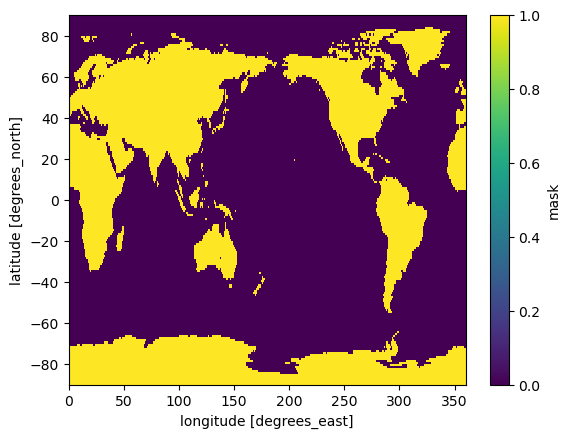

In [126]:
# Read reference mask
path_masks = '/Users/kyrab/Github/SLBudget/data/Masks/'
masks_ds = xr.open_dataset(f'{path_masks}reference_masks.nc')

landsea = xr.where(masks_ds.mask==1, 0, 1)
landsea.plot()


In [120]:


# Calculate the colatitude in radians: 
th = (90 - lat_target)*np.pi/180.0
LMAX = 360
LOVE = gravtk.load_love_numbers(LMAX)
PLM, dPLM = gravtk.plm_holmes(LMAX, np.cos(th))
LOVE0 = (LOVE[0]-LOVE[0], LOVE[1]-LOVE[1], LOVE[2]-LOVE[2])

In [121]:
# Method 2 from notebook ComputeGRD

Ylms = gravtk.gen_stokes(totalant.data.T, lon_target, lat_target, UNITS=3, LMIN=0, LMAX=LMAX, LOVE=LOVE, PLM=PLM)
Ylms_L0 = gravtk.gen_stokes(totalant.data.T, lon_target, lat_target, UNITS=3, LMIN=0, LMAX=LMAX, LOVE=LOVE0, PLM=PLM)

Ylms

print("Ylms.clm shape:", Ylms.clm.shape)
print("lon_target:", len(lon_target))
print("lat_target:", len(lat_target))
print("landsea shape:", landsea.shape)
print('lalal')

Ylms.clm shape: (361, 361)
lon_target: 360
lat_target: 180
landsea shape: (180, 360)


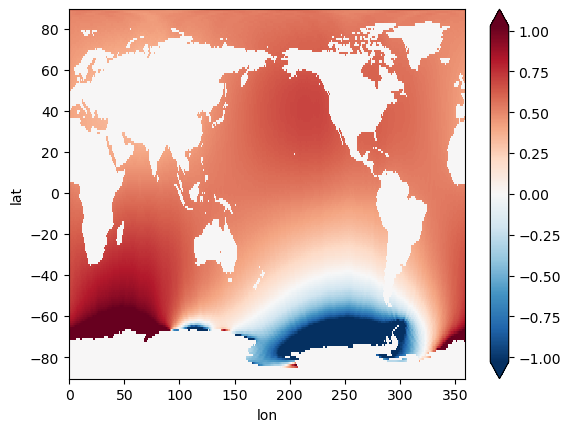

In [130]:
rsl = gravtk.sea_level_equation(Ylms.clm, Ylms.slm, lon_target, lat_target, landsea.data.T,
    LMAX=LMAX, PLM=PLM, LOVE=LOVE, ITERATIONS=6, POLAR=True)

rsl_da = xr.DataArray(
    data=rsl.T,              # transpose if needed
    dims=["lat", "lon"],     # match array shape
    coords={"lat": lat_target, "lon": lon_target}
)

rsl_da.plot(robust=True, cmap="RdBu_r")

#rsl_da = xr.DataArray(data=rsl, 
#                       dims=['lon', 'lat'],
#                      coords=['lon': lon_target, 'lat': lat_target])

#rsl_da.T.plot(robust=True)

# Other things to try 
Soort of interpolation try but fail

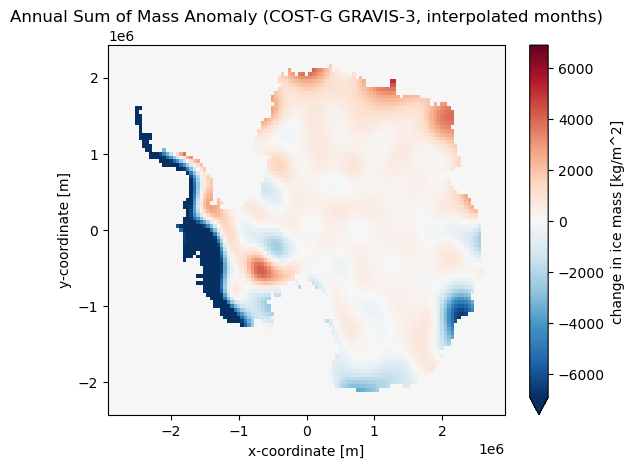

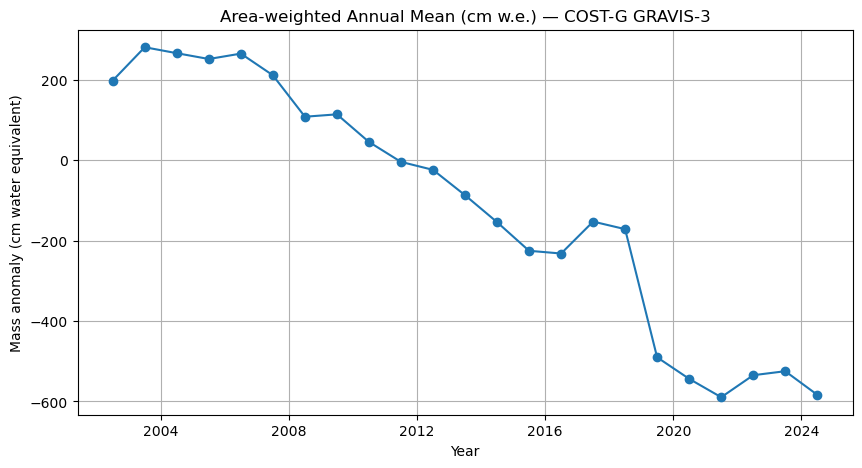

In [86]:
# Step 1 — Interpolate missing months along the time dimension
dm_interp = ant["dm"].interpolate_na(dim="time", method="linear")

# Step 2 — Group by year and sum (combine all months of each year)
dm_yearly_sum = dm_interp.groupby("time.year").sum(dim="time")

# Step 3 — Convert 'year' to datetime-like coordinate for easy plotting
dm_yearly_sum = dm_yearly_sum.assign_coords(
    time=("year", [np.datetime64(f"{y}-07-01") for y in dm_yearly_sum.year.values])
).swap_dims({"year": "time"}).drop_vars("year")

# Step 4 — (optional) Plot one yearly field, e.g. 2015
dm_yearly_sum.sel(time="2015-07-01").plot(cmap="RdBu_r", robust=True)
plt.title("Annual Sum of Mass Anomaly (COST-G GRAVIS-3, interpolated months)")
plt.show()

# Step 5 — (optional) Area-weighted annual mean time series
dm_annual_mean = (dm_yearly_sum * ant["area"]).sum(dim=("y", "x")) / ant["area"].sum()
plt.figure(figsize=(10,5))
plt.plot(dm_annual_mean["time"], dm_annual_mean, marker="o")
plt.title("Area-weighted Annual Mean (cm w.e.) — COST-G GRAVIS-3")
plt.ylabel("Mass anomaly (cm water equivalent)")
plt.xlabel("Year")
plt.grid(True)
plt.show()